# Hillstrom Promotion Uplift Analysis

**Project context / 项目背景：**  
This notebook analyzes a randomized email promotion experiment as a cross-border e-commerce CRM decision problem. The goal is to estimate incremental conversion and spend, then compare broad rollout against targeted rollout.

**Business question:**  
For a cross-border e-commerce CRM team, which campaign rollout policy creates the best incremental business value?

**What this notebook shows:**  
1. Experiment quality and sample split  
2. Global A/B test readout  
3. Segment uplift discovery  
4. Cost-adjusted policy simulation  
5. Business recommendation

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ["MPLCONFIGDIR"] = str(PROJECT_ROOT / ".mplconfig")
(PROJECT_ROOT / ".mplconfig").mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "hillstrom_email.csv"
SEGMENT_PATH = PROJECT_ROOT / "data" / "processed" / "segment_uplift.csv"
POLICY_PATH = PROJECT_ROOT / "data" / "processed" / "policy_simulation.csv"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load Data

Dataset: Hillstrom email experiment.  
The data contains a no-email holdout arm and two category email treatment arms.

In [2]:
df = pd.read_csv(RAW_PATH)
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Rows: 64,000
Columns: 12


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [3]:
sample_split = (
    df["segment"]
    .value_counts()
    .rename_axis("experiment_arm")
    .reset_index(name="users")
    .sort_values("experiment_arm")
)
sample_split["share"] = sample_split["users"] / sample_split["users"].sum()
display(sample_split)

,experiment_arm,users,share
1,Mens E-Mail,21307,0.332922
2,No E-Mail,21306,0.332906
0,Womens E-Mail,21387,0.334172


**Readout:** the three experiment arms are almost evenly split, so this is a clean randomized experiment for A/B readout.

## 2. Global Experiment Readout

Start with the simple question: did each email treatment beat the no-email holdout?

In [4]:
arm_summary = (
    df.groupby("segment")
    .agg(
        users=("segment", "size"),
        visit_rate=("visit", "mean"),
        conversion_rate=("conversion", "mean"),
        spend_per_customer=("spend", "mean"),
    )
    .reset_index()
)
display(arm_summary)

,segment,users,visit_rate,conversion_rate,spend_per_customer
0,Mens E-Mail,21307,0.182757,0.012531,1.422617
1,No E-Mail,21306,0.106167,0.005726,0.652789
2,Womens E-Mail,21387,0.151400,0.008837,1.077202


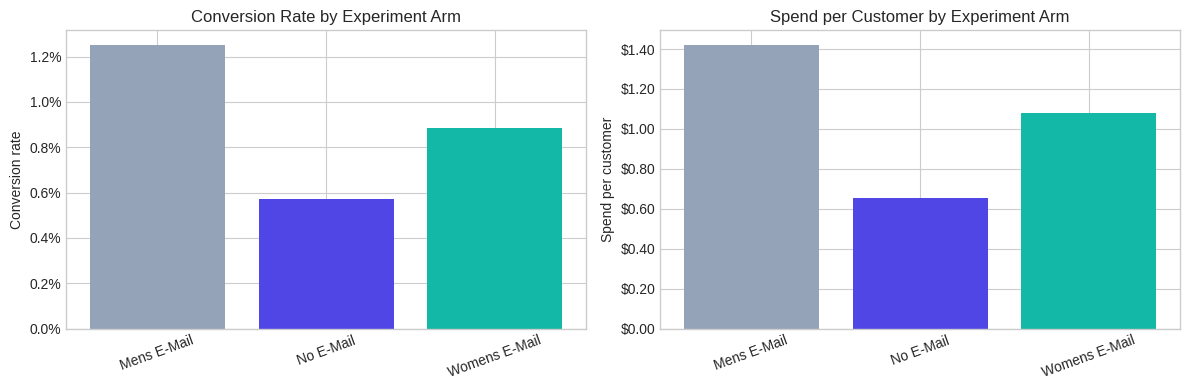

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(arm_summary["segment"], arm_summary["conversion_rate"], color=["#94a3b8", "#4f46e5", "#14b8a6"])
axes[0].set_title("Conversion Rate by Experiment Arm")
axes[0].set_ylabel("Conversion rate")
axes[0].tick_params(axis="x", rotation=20)
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")

axes[1].bar(arm_summary["segment"], arm_summary["spend_per_customer"], color=["#94a3b8", "#4f46e5", "#14b8a6"])
axes[1].set_title("Spend per Customer by Experiment Arm")
axes[1].set_ylabel("Spend per customer")
axes[1].tick_params(axis="x", rotation=20)
axes[1].yaxis.set_major_formatter(lambda x, _: f"${x:.2f}")

plt.tight_layout()
plt.show()

In [6]:
def two_prop_test(control, treatment):
    n_c, n_t = len(control), len(treatment)
    x_c, x_t = control.sum(), treatment.sum()
    p_c, p_t = x_c / n_c, x_t / n_t
    pooled = (x_c + x_t) / (n_c + n_t)
    se_pooled = (pooled * (1 - pooled) * (1 / n_c + 1 / n_t)) ** 0.5
    z = (p_t - p_c) / se_pooled
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    se_unpooled = (p_c * (1 - p_c) / n_c + p_t * (1 - p_t) / n_t) ** 0.5
    diff = p_t - p_c
    return p_c, p_t, diff, p_value, diff - 1.96 * se_unpooled, diff + 1.96 * se_unpooled

def mean_diff_test(control, treatment):
    c, t = control.fillna(0), treatment.fillna(0)
    _, p_value = stats.ttest_ind(t, c, equal_var=False)
    diff = t.mean() - c.mean()
    se = (c.var(ddof=1) / len(c) + t.var(ddof=1) / len(t)) ** 0.5
    return c.mean(), t.mean(), diff, p_value, diff - 1.96 * se, diff + 1.96 * se

control = df[df["segment"] == "No E-Mail"]
effect_rows = []
for treatment_name in ["Mens E-Mail", "Womens E-Mail"]:
    treatment = df[df["segment"] == treatment_name]
    _, _, conv_lift, conv_p, conv_ci_lo, conv_ci_hi = two_prop_test(control["conversion"], treatment["conversion"])
    _, _, spend_lift, spend_p, spend_ci_lo, spend_ci_hi = mean_diff_test(control["spend"], treatment["spend"])
    effect_rows.append({
        "treatment": treatment_name,
        "conv_lift": conv_lift,
        "conv_95ci": f"[{conv_ci_lo:.2%}, {conv_ci_hi:.2%}]",
        "conv_p": conv_p,
        "incr_conv_per_100k": conv_lift * 100_000,
        "spend_lift_per_user": spend_lift,
        "spend_95ci": f"[${spend_ci_lo:.3f}, ${spend_ci_hi:.3f}]",
        "spend_p": spend_p,
        "incr_spend_per_100k": spend_lift * 100_000,
    })

effects = pd.DataFrame(effect_rows)
display(effects.style.format({
    "conv_lift": "{:.2%}",
    "conv_p": "{:.2e}",
    "incr_conv_per_100k": "{:,.0f}",
    "spend_lift_per_user": "${:,.3f}",
    "spend_p": "{:.2e}",
    "incr_spend_per_100k": "${:,.0f}",
}))


,treatment,conv_lift,conv_95ci,conv_p,incr_conv_per_100k,spend_lift_per_user,spend_95ci,spend_p,incr_spend_per_100k
0,Mens E-Mail,0.68%,"[0.50%, 0.86%]",1.52e-13,681,$0.770,"[$0.485, $1.055]",1.16e-07,"$76,983"
1,Womens E-Mail,0.31%,"[0.15%, 0.47%]",1.57e-04,311,$0.424,"[$0.169, $0.680]",1.13e-03,"$42,441"


**Business read / 中文解读：**  
Mens E-Mail is the strongest global treatment. It improves both conversion and spend versus the no-email holdout, so it is a reasonable first candidate for rollout.

但平均有效不等于应该全量发。CRM 的关键问题是：哪些用户真的有增量，哪些用户可能只是被打扰或浪费优惠券。

## 3. Segment Uplift Discovery

Use existing customer features to find high-uplift and low-uplift groups.  
This turns a global experiment readout into a customer targeting decision.

In [7]:
segment_uplift = pd.read_csv(SEGMENT_PATH)
top_targets = (
    segment_uplift[segment_uplift["policy"] == "target"]
    .sort_values("incremental_spend_per_100k", ascending=False)
    .head(8)
)
display(top_targets[
    [
        "segment_dimension",
        "segment_value",
        "treatment",
        "n_control",
        "n_treatment",
        "conversion_lift",
        "spend_lift",
        "incremental_spend_per_100k",
        "policy",
    ]
])

,segment_dimension,segment_value,treatment,n_control,n_treatment,conversion_lift,spend_lift,incremental_spend_per_100k,policy
10,category_history,Both mens and womens,Mens E-Mail,2149,2181,0.014994,1.824986,182498.642086,target
11,history_segment,4) $350 - $500,Mens E-Mail,2124,2097,0.008729,1.568940,156894.003136,target
12,history_segment,"6) $750 - $1,000",Mens E-Mail,622,644,0.020022,1.534146,153414.636217,target
13,history_segment,5) $500 - $750,Womens E-Mail,1652,1662,0.010196,1.285651,128565.068633,target
14,channel,Multichannel,Mens E-Mail,2606,2577,0.010167,1.209129,120912.940526,target
15,channel,Multichannel,Womens E-Mail,2606,2579,0.007052,1.157536,115753.586513,target
16,history_segment,5) $500 - $750,Mens E-Mail,1652,1597,0.008328,1.103010,110301.006654,target
17,recency_band,1-3 months,Mens E-Mail,7438,7469,0.007326,1.047598,104759.806249,target


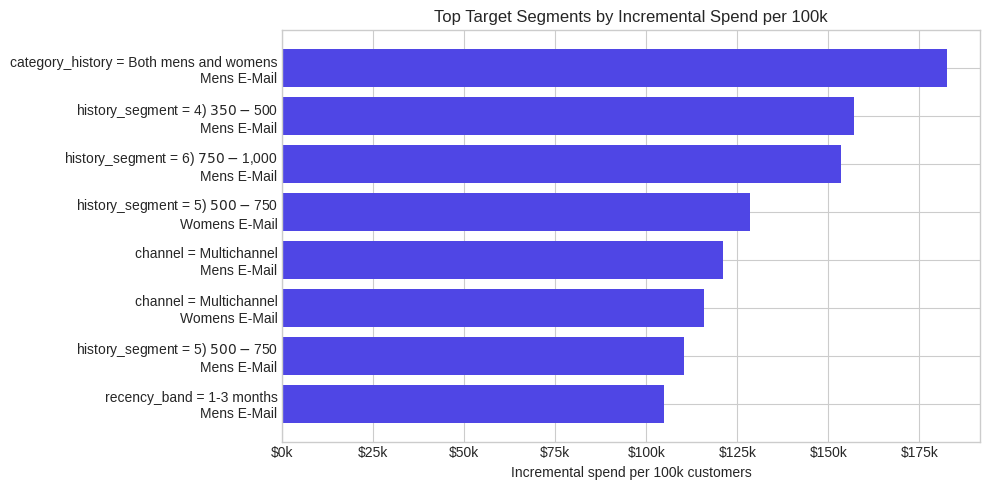

In [8]:
plot_df = top_targets.sort_values("incremental_spend_per_100k")
labels = plot_df["segment_dimension"] + " = " + plot_df["segment_value"] + "\n" + plot_df["treatment"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels, plot_df["incremental_spend_per_100k"], color="#4f46e5")
ax.set_title("Top Target Segments by Incremental Spend per 100k")
ax.set_xlabel("Incremental spend per 100k customers")
ax.xaxis.set_major_formatter(lambda x, _: f"${x/1000:.0f}k")
plt.tight_layout()
plt.show()

In [9]:
suppress = (
    segment_uplift[segment_uplift["policy"] == "suppress"]
    .sort_values("incremental_spend_per_100k")
    .head(6)
)
display(suppress[
    [
        "segment_dimension",
        "segment_value",
        "treatment",
        "conversion_lift",
        "spend_lift",
        "incremental_spend_per_100k",
        "policy",
    ]
])

,segment_dimension,segment_value,treatment,conversion_lift,spend_lift,incremental_spend_per_100k,policy
9,history_segment,3) $200 - $350,Womens E-Mail,-0.000666,-0.323141,-32314.073888,suppress
8,history_segment,4) $350 - $500,Womens E-Mail,-0.002159,-0.100890,-10088.993379,suppress


**Business read / 中文解读：**  
The target groups are not simply “everyone who bought before.” The strongest signal is category fit and historical value, especially users with both mens and womens history and high historical spend bands.

这一步把实验结果翻译成 CRM 人群策略：`target`、`suppress`、`retest`。

## 4. Policy Simulation

Compare four rollout policies:

- No campaign holdout
- Send all Mens E-Mail
- Send all Womens E-Mail
- Rule-based target/suppress

The important twist: when every touch has coupon/contact cost, the best gross-spend policy may not be the best business policy.

In [10]:
policy = pd.read_csv(POLICY_PATH)
display(policy[
    [
        "policy",
        "contacted_share",
        "conversion_rate",
        "spend_per_customer",
        "expected_conversions_per_100k",
        "expected_spend_per_100k",
        "contact_cost_per_100k",
        "cost_adjusted_value_per_100k",
        "incremental_spend_vs_holdout",
    ]
])

,policy,contacted_share,conversion_rate,spend_per_customer,expected_conversions_per_100k,expected_spend_per_100k,contact_cost_per_100k,cost_adjusted_value_per_100k,incremental_spend_vs_holdout
0,Send all Mens E-Mail,1.000000,0.012531,1.422617,1253.109307,142261.651101,55000.0000,87261.651101,76982.715589
1,Send all Womens E-Mail,1.000000,0.008837,1.077202,883.714406,107720.157105,55000.0000,52720.157105,42441.221594
2,Rule-based target/suppress,0.295187,0.008951,1.065247,895.110989,106524.730876,16235.3125,90289.418376,41245.795365
3,No campaign holdout,0.000000,0.005726,0.652789,572.608655,65278.935511,0.0000,65278.935511,0.000000


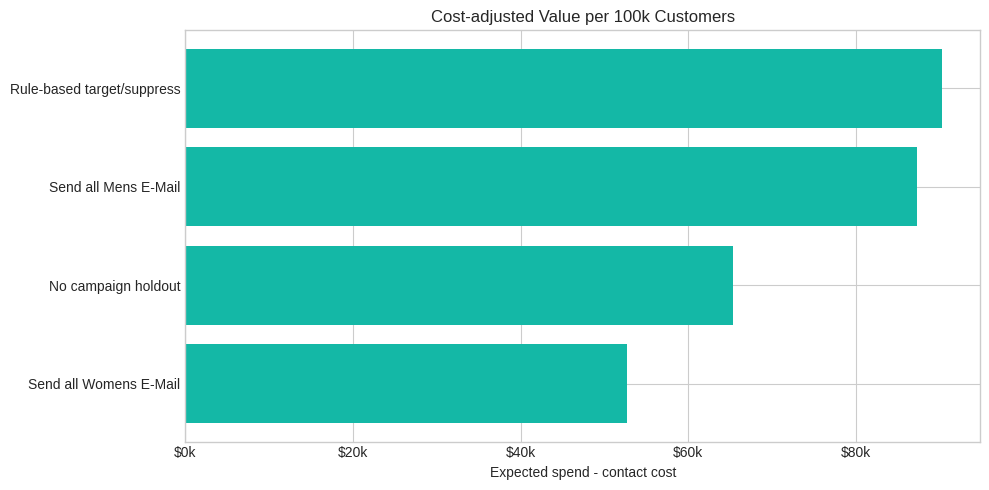

In [11]:
policy_plot = policy.sort_values("cost_adjusted_value_per_100k")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(policy_plot["policy"], policy_plot["cost_adjusted_value_per_100k"], color="#14b8a6")
ax.set_title("Cost-adjusted Value per 100k Customers")
ax.set_xlabel("Expected spend - contact cost")
ax.xaxis.set_major_formatter(lambda x, _: f"${x/1000:.0f}k")
plt.tight_layout()
plt.show()

In [12]:
best_gross = policy.sort_values("expected_spend_per_100k", ascending=False).iloc[0]
best_cost_adjusted = policy.sort_values("cost_adjusted_value_per_100k", ascending=False).iloc[0]

print(f"Best gross spend policy: {best_gross['policy']} (${best_gross['expected_spend_per_100k']:,.0f} per 100k)")
print(
    f"Best cost-adjusted policy: {best_cost_adjusted['policy']} "
    f"(${best_cost_adjusted['cost_adjusted_value_per_100k']:,.0f} per 100k)"
)

Best gross spend policy: Send all Mens E-Mail ($142,262 per 100k)
Best cost-adjusted policy: Rule-based target/suppress ($90,289 per 100k)


## 5. Business Recommendation

**Recommendation:**  
Roll out a targeted CRM policy rather than blindly sending to everyone, then use this rule-based policy as the baseline for the next uplift model.

**中文业务结论：**  
标准 A/B readout 显示，男装邮件相对 holdout 同时提升转化和 spend。分层 uplift 进一步显示，促销效果集中在特定用户群，而不是所有用户都适合被触达。Policy simulation 对比了全量发送、女装全量、男装全量和规则定向触达。结果显示：如果只看 gross spend，全量男装邮件最好；但如果考虑优惠券或触达成本，定向策略的成本调整价值更高。

**Next phase:**  
Train an uplift model on top of this rule baseline and compare top-decile targeting against the current rule-based policy.